## Francisco Tinoco

* Clase 26 -03

In [4]:
import pandas as pd

In [5]:
import kagglehub
path = kagglehub.dataset_download("shantanugarg274/heart-prediction-dataset-quantum")
print("Path to dataset files:", path)

c:\Users\Francisco\anaconda3\envs\nuevo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Francisco\.cache\kagglehub\datasets\shantanugarg274\heart-prediction-dataset-quantum\versions\1


In [34]:
df = pd.read_csv("C:\\Users\\Francisco\\Downloads\\8vo Semestre\\Lab estadistico\\Lab-Aprendizaje-Estadistico\\Acts\\Act05\\Heart Prediction Quantum Dataset.csv")
df

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1
...,...,...,...,...,...,...,...
495,34,0,126,292,116,9.303403,0
496,41,0,164,248,114,9.067889,0
497,45,1,159,175,75,8.718708,0
498,55,0,107,157,101,7.337650,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


#### Histogramas para ver las distribuciones y si alguna variable está sesgada :

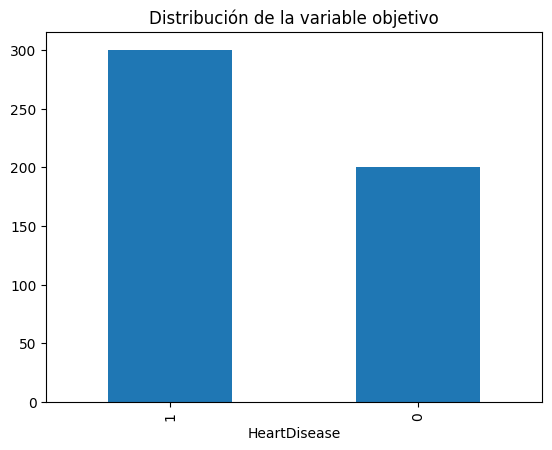

In [35]:
import matplotlib.pyplot as plt

df['HeartDisease'].value_counts().plot(kind='bar')
plt.title('Distribución de la variable objetivo')
plt.show()

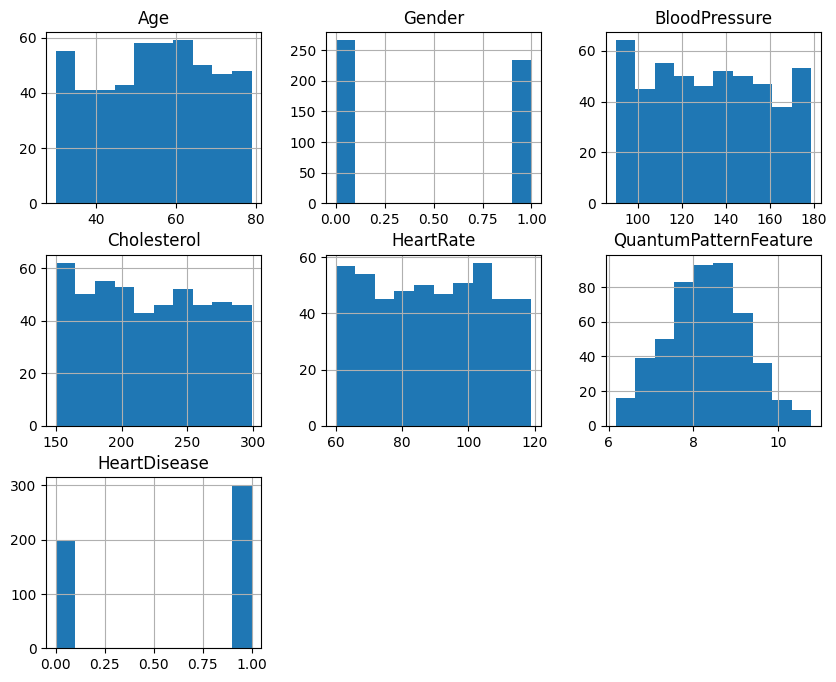

In [36]:
!pip install seaborn
import seaborn as sns

df.hist(figsize=(10,8))
plt.show()

In [12]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


- No hay valores nulos en el dataset
- Las variables son completamente numéricas
- La variable objetivo está relativamente balanceada
- Algunas variables muestran correlación moderada con HeartDisease
- No se observan outliers extremos que requieran limpieza inmediata

### Dividimos en X, y ; 

* Empezamos definiendo nuestro modelo MLP para clasificar 'HeartDisease'

In [37]:
from sklearn.neural_network import MLPClassifier

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop(['HeartDisease', 'QuantumPatternFeature'], axis=1)
y = df['HeartDisease']

In [40]:
X

,Age,Gender,BloodPressure,Cholesterol,HeartRate
0,68,1,105,191,107
1,58,0,97,249,89
2,44,0,93,190,82
3,72,1,93,183,101
4,37,0,145,166,103
...,...,...,...,...,...
495,34,0,126,292,116
496,41,0,164,248,114
497,45,1,159,175,75
498,55,0,107,157,101


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [43]:
mlp = MLPClassifier(
    hidden_layer_sizes=(5,10),
    random_state=42
)

mlp.fit(X_train, y_train)

c:\Users\Francisco\anaconda3\envs\nuevo\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42)

In [44]:
y_pred = mlp.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.8

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.86      0.60      0.71        40
           1       0.78      0.93      0.85        60

    accuracy                           0.80       100
   macro avg       0.82      0.77      0.78       100
weighted avg       0.81      0.80      0.79       100



El parámetro hidden_layer_sizes=(5,10) indica que la red neuronal tiene:

- 2 capas ocultas
- Primera capa: 5 neuronas
- Segunda capa: 10 neuronas

Esto permite que el modelo capture relaciones no lineales en los datos, aumentando su capacidad de aprendizaje comparado con modelos lineales.

In [47]:
# ## Hacer curva roc para estos datos con K= 10

# ## Con el codigo de optimizacion bayesiana busquemos la mejor combinacion de capas para estos rangos, 
# son 3 capas :

# [2, 6],  [5,15] y [3,16] y obtener la mejor combinacion 